In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv(r"C:\Users\Deepika B R\Downloads\train.csv.zip")
stores = pd.read_csv(r"C:\Users\Deepika B R\Downloads\stores.csv")
features = pd.read_csv(r"C:\Users\Deepika B R\Downloads\features.csv")

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [6]:
train.shape

(421570, 5)

In [7]:
stores.shape

(45, 3)

In [8]:
features.shape

(8190, 12)

In [9]:
df = pd.merge(
    train,
    stores,
    on="Store",
    how="left"
)

In [10]:
df = pd.merge(
    df,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

In [11]:
df.shape

(421570, 16)

In [12]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [14]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

In [15]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [16]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64

In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week

In [19]:
df[["Date","Year","Month","Week"]].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


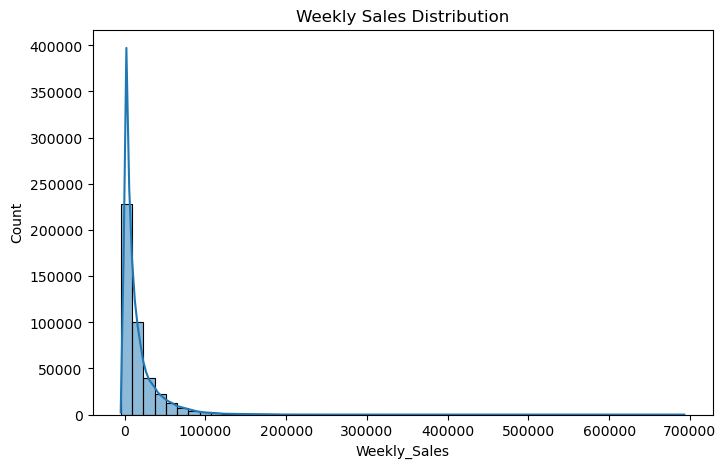

In [20]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.histplot(
    df["Weekly_Sales"],
    bins=50,
    kde=True
)

plt.title("Weekly Sales Distribution")
plt.show()

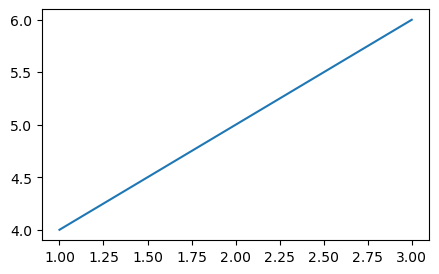

In [21]:
plt.figure(figsize=(5,3))
plt.plot([1,2,3],[4,5,6])
plt.show()

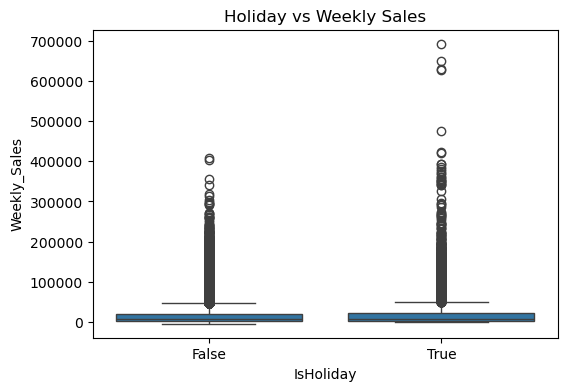

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="IsHoliday",
    y="Weekly_Sales",
    data=df
)

plt.title("Holiday vs Weekly Sales")
plt.show()

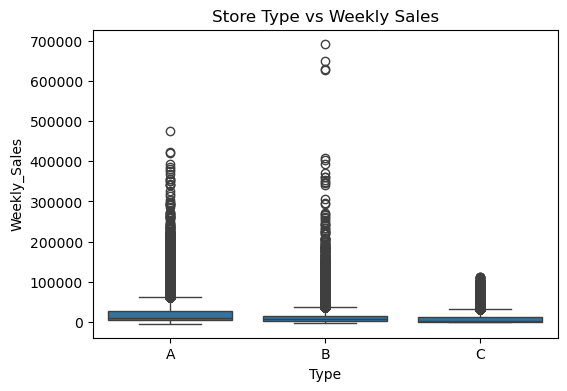

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Type",
    y="Weekly_Sales",
    data=df
)

plt.title("Store Type vs Weekly Sales")
plt.show()

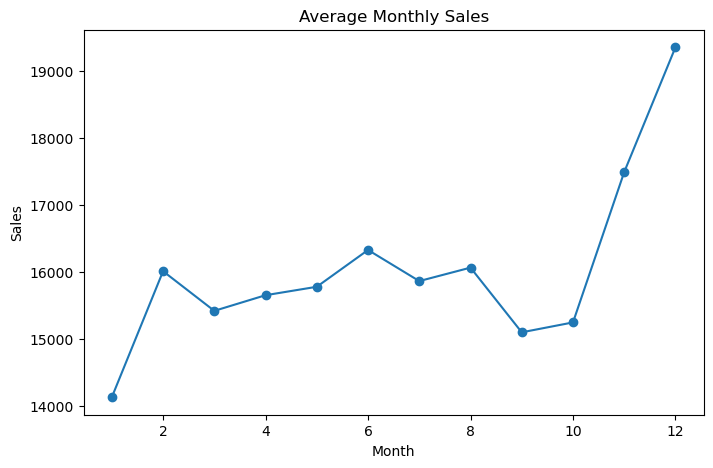

In [24]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].mean()

monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Average Monthly Sales")
plt.ylabel("Sales")
plt.show()

In [25]:
df.drop("Date", axis=1, inplace=True)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [27]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
X.shape

(421570, 17)

In [30]:
df.isnull().sum().sum()

np.int64(0)

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_lr)

mse = mean_squared_error(y_test, y_pred_lr)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 14551.83836466214
RMSE: 21789.21514321596
R2 Score: 0.08955646039425069


In [39]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [40]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = mean_squared_error(
    y_test,
    y_pred_dt
) ** 0.5

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE : 1871.0648459330596
RMSE: 4860.893824945197
R2 Score: 0.954689159895555


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [36]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE : 1487.1639913656095
RMSE: 3798.629857404541
R2 Score: 0.972329067214391


In [41]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Dept,0.626848
4,Size,0.191242
0,Store,0.056419
16,Week,0.039342
12,CPI,0.026664
3,Type,0.014513
13,Unemployment,0.010834
5,Temperature,0.010101
15,Month,0.007694
6,Fuel_Price,0.005165


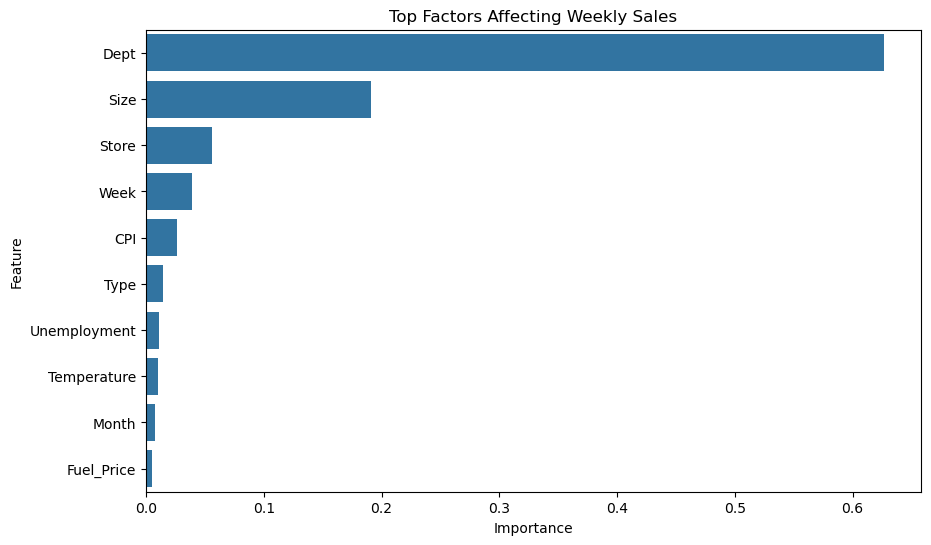

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top Factors Affecting Weekly Sales")

plt.show()

A Sales Forecasting System was developed using the Walmart Sales dataset. Multiple datasets were merged, cleaned, and preprocessed. Exploratory Data Analysis was performed to understand the impact of store characteristics, holidays, economic indicators, and promotional markdowns on sales performance.

Three regression models were evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. Random Forest Regressor achieved the best performance with an MAE of 1487.16, RMSE of 3798.63, and R² Score of 0.9723.

The results indicate that ensemble learning methods effectively capture complex sales patterns and can provide highly accurate sales forecasts for retail businesses.